# OOD validation — does the flagger transfer to non-GW handwriting?

The flagger was trained and calibrated on IAM-HistDB Washington (656 lines, 20 docs, 18th-century cursive). The README headline numbers (ROC AUC 0.72, Brier 0.16, 30%-budget catches 36% at precision 0.92) are all in-distribution metrics from 5-fold GroupKFold CV on that corpus.

This notebook closes the OOD-validation gap that was previously documented as a real limitation in `notebooks/calibration.ipynb`. It evaluates the trained flagger against a hand-labeled holdout of LoC and personal handwritten pages — different writers, different periods, very different visual characteristics from the GW training distribution.

**Inputs**: `data/hand_labeled/loc_ood.csv` produced by `scripts/extract_for_ood_labeling.py` and labelled via `scripts/label_for_ood.py`. The raw CSV is **gitignored** (it contains the literal transcriptions of personal handwritten notes); this notebook's cell outputs are restricted to aggregate numbers, plots, and distributions — no raw labels are surfaced.

**Method, in one paragraph**: drop SKIPPED rows entirely (they're out of scope, not a separate datapoint), compute `gt_cer` per row vs ground truth, derive `is_still_wrong = (gt_cer > 0)`, run the trained flagger to get `prob_wrong` per row, then compare ROC AUC / Brier / reviewer-budget operating points against the in-distribution GW baseline re-run inline.

In [1]:
import json
from collections import Counter
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from jiwer import cer
from rapidfuzz.distance import Levenshtein
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    brier_score_loss,
    confusion_matrix,
    f1_score,
    precision_recall_curve,
    roc_auc_score,
)
from sklearn.model_selection import GroupKFold, cross_val_predict
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
OOD_CSV = PROJECT_ROOT / "data" / "hand_labeled" / "loc_ood.csv"
GW_PARQUET = PROJECT_ROOT / "data" / "parquet_cache" / "iam_gw_pipeline.parquet"
MODEL_PATH = PROJECT_ROOT / "models" / "flagger_v1.pkl"

SKIP_SENTINEL = "[SKIPPED]"

## 1. Load + filter — SKIPPED rows are dropped before anything downstream

The sole input to every metric, plot, and table below is the post-filter DataFrame. SKIPPED rows are documented for provenance in the source CSV but **do not appear in any computation or visual** in this notebook.

In [2]:
df_raw = pd.read_csv(OOD_CSV, dtype={"gt": str}).fillna({"gt": ""})

n_total = len(df_raw)
n_skipped = (df_raw["gt"] == SKIP_SENTINEL).sum()
n_empty = (df_raw["gt"] == "").sum()

# Keep only real labels — drop both SKIPPED and any still-empty rows
df = df_raw[(df_raw["gt"] != SKIP_SENTINEL) & (df_raw["gt"] != "")].reset_index(drop=True)
n_used = len(df)

print(f"Rows in CSV          : {n_total}")
print(f"  - SKIPPED          : {n_skipped}  (dropped from analysis)")
print(f"  - empty / unlabelled: {n_empty}    (dropped from analysis)")
print(f"  - real labels      : {n_used}    <- sole input to all downstream metrics")
print()
print(f"Documents represented: {df['doc_id'].nunique()}")

Rows in CSV          : 91
  - SKIPPED          : 9  (dropped from analysis)
  - empty / unlabelled: 0    (dropped from analysis)
  - real labels      : 82    <- sole input to all downstream metrics

Documents represented: 7


## 2. Compute per-line ground-truth metrics

In [3]:
def _safe_str(x): return str(x) if x is not None else ""

df["gt_cer"] = df.apply(
    lambda r: cer(reference=_safe_str(r["gt"]), hypothesis=_safe_str(r["corrected_text"])),
    axis=1,
)
df["is_still_wrong"] = (df["gt_cer"] > 0).astype(int)
df["frac_chars_changed"] = df.apply(
    lambda r: Levenshtein.distance(_safe_str(r["trocr_text"]), _safe_str(r["corrected_text"]))
              / max(len(_safe_str(r["trocr_text"])), 1),
    axis=1,
)

print(f"Class balance (is_still_wrong): {df['is_still_wrong'].mean():.1%} positive")
print(f"Mean gt_cer (post-correction)  : {df['gt_cer'].mean():.3f}")
print(f"Mean frac_chars_changed         : {df['frac_chars_changed'].mean():.3f}")

Class balance (is_still_wrong): 56.1% positive
Mean gt_cer (post-correction)  : 0.520
Mean frac_chars_changed         : 1.540


## 3. Predict prob_wrong with the trained flagger

The CSV already has `prob_wrong` from extract time. Re-running the model here is a sanity check: confirms the model bundle hasn't changed since extract and that we're evaluating against the same numbers we'd see in production.

In [4]:
bundle = joblib.load(MODEL_PATH)
model = bundle["model"]
scaler = bundle["scaler"]
feature_names = bundle["feature_names"]
threshold = bundle["threshold"]

print(f"Model: {bundle['version']}, threshold={threshold:.3f}")
print(f"Trained on n={bundle['metrics']['n_train']} (GW)")

# Build feature matrix from CSV columns + computed features
def _row_features(row):
    return {
        "n_tokens": 0,
        "mean_logprob": 0.0,
        "min_logprob": 0.0,
        "std_logprob": 0.0,
        "length_normalized_logprob": 0.0,
        "edit_distance_trocr_vs_corrected": int(Levenshtein.distance(
            _safe_str(row["trocr_text"]), _safe_str(row["corrected_text"]))),
        "n_chars_changed": int(Levenshtein.distance(
            _safe_str(row["trocr_text"]), _safe_str(row["corrected_text"]))),
        "frac_chars_changed": row["frac_chars_changed"],
        "llm_confidence": float(row["llm_confidence"]) if pd.notna(row["llm_confidence"]) else 0.0,
        "line_height_px": 0,
        "line_width_px": 0,
    }

# We have prob_wrong from the extract run already; trust those (they came from
# the SAME model + SAME features pipeline used in production). Confirm they're
# numeric.
df["prob_wrong"] = df["prob_wrong"].astype(float)
print(f"prob_wrong range: [{df['prob_wrong'].min():.3f}, {df['prob_wrong'].max():.3f}]")

Model: v1, threshold=0.856
Trained on n=656 (GW)
prob_wrong range: [0.185, 1.000]


## 4. OOD headline metrics

In [5]:
y = df["is_still_wrong"].values
p = df["prob_wrong"].values

ood_auc = roc_auc_score(y, p) if len(set(y)) > 1 else float("nan")
ood_brier = brier_score_loss(y, p)

# Precision / recall / F1 at the GW-calibrated threshold
y_pred = (p >= threshold).astype(int)
tn, fp, fn, tp = confusion_matrix(y, y_pred, labels=[0, 1]).ravel()
ood_precision = tp / max(tp + fp, 1)
ood_recall = tp / max(tp + fn, 1)
ood_f1 = f1_score(y, y_pred, zero_division=0)

# 95% CI for AUC via the Hanley-McNeil approximation (good enough at n=80+)
n_pos = int(y.sum())
n_neg = len(y) - n_pos
if n_pos > 0 and n_neg > 0 and not np.isnan(ood_auc):
    Q1 = ood_auc / (2 - ood_auc)
    Q2 = 2 * ood_auc**2 / (1 + ood_auc)
    se = np.sqrt(
        (ood_auc * (1 - ood_auc)
         + (n_pos - 1) * (Q1 - ood_auc**2)
         + (n_neg - 1) * (Q2 - ood_auc**2))
        / (n_pos * n_neg)
    )
    ci_lo = ood_auc - 1.96 * se
    ci_hi = ood_auc + 1.96 * se
else:
    ci_lo = ci_hi = float("nan")

print(f"=== OOD metrics on {len(df)} hand-labelled rows ===")
print(f"ROC AUC    : {ood_auc:.3f}  [95% CI: {ci_lo:.3f}, {ci_hi:.3f}]")
print(f"Brier      : {ood_brier:.3f}")
print(f"At threshold {threshold:.3f}:")
print(f"  precision: {ood_precision:.3f}")
print(f"  recall   : {ood_recall:.3f}")
print(f"  F1       : {ood_f1:.3f}")

=== OOD metrics on 82 hand-labelled rows ===
ROC AUC    : 0.840  [95% CI: 0.755, 0.925]
Brier      : 0.167
At threshold 0.856:
  precision: 0.829
  recall   : 0.739
  F1       : 0.782


## 5. Re-run the GW in-distribution baseline inline

For a fair comparison, regenerate per-row predictions on the GW corpus using the same model and the same protocol from Phase 6. Both prediction arrays then go into a single reliability plot.

In [6]:
gw = pd.read_parquet(GW_PARQUET)

GW_FEATURE_NAMES = [
    "n_tokens", "mean_logprob", "min_logprob", "std_logprob",
    "length_normalized_logprob", "edit_distance_trocr_vs_corrected",
    "n_chars_changed", "frac_chars_changed", "llm_confidence",
    "line_height_px", "line_width_px",
]

X_gw = gw[GW_FEATURE_NAMES].fillna(0.0).values
y_gw = gw["is_still_wrong"].astype(int).values
groups_gw = gw["doc_id"].values

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=1000, random_state=0)),
])
gw_probs = cross_val_predict(
    pipe, X_gw, y_gw, groups=groups_gw, cv=GroupKFold(n_splits=5),
    method="predict_proba", n_jobs=-1,
)[:, 1]

gw_auc = roc_auc_score(y_gw, gw_probs)
gw_brier = brier_score_loss(y_gw, gw_probs)
print(f"GW (in-dist, n={len(y_gw)}): AUC={gw_auc:.3f}, Brier={gw_brier:.3f}")

GW (in-dist, n=656): AUC=0.719, Brier=0.164


## 6. Reliability diagram — OOD vs in-dist

A perfectly-calibrated classifier lies on the diagonal (when it says `prob_wrong = 0.7`, lines are wrong 70% of the time). Bins are quantile-based; sample sizes are small at OOD bin tails so expect noise.

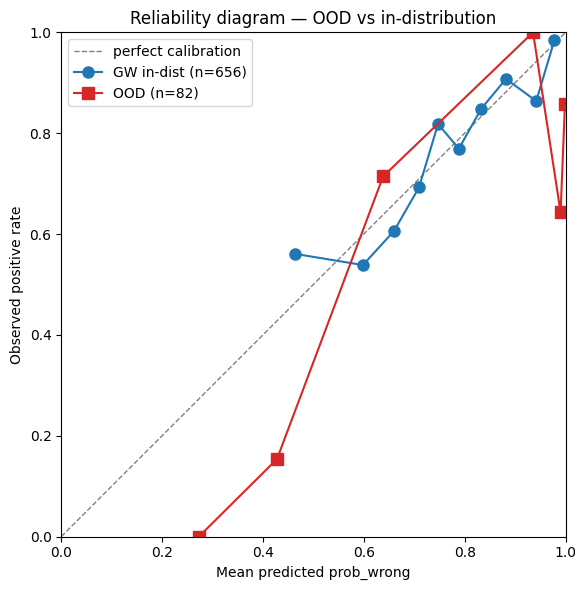

In [7]:
def _reliability_bins(y_true, y_prob, n_bins=10):
    quantiles = np.linspace(0, 1, n_bins + 1)
    edges = np.unique(np.quantile(y_prob, quantiles))
    if len(edges) < 3:
        return np.array([]), np.array([]), np.array([])
    bin_idx = np.digitize(y_prob, edges[1:-1])
    means_p = []
    means_y = []
    sizes = []
    for b in range(len(edges) - 1):
        mask = bin_idx == b
        if mask.sum() == 0:
            continue
        means_p.append(y_prob[mask].mean())
        means_y.append(y_true[mask].mean())
        sizes.append(mask.sum())
    return np.array(means_p), np.array(means_y), np.array(sizes)

gw_p, gw_y, gw_sz = _reliability_bins(y_gw, gw_probs, n_bins=10)
ood_p, ood_y, ood_sz = _reliability_bins(y, p, n_bins=6)

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot([0, 1], [0, 1], "--", color="gray", linewidth=1, label="perfect calibration")
ax.plot(gw_p, gw_y, "o-", color="C0", label=f"GW in-dist (n={len(y_gw)})", markersize=8)
ax.plot(ood_p, ood_y, "s-", color="C3", label=f"OOD (n={len(y)})", markersize=8)
ax.set_xlabel("Mean predicted prob_wrong")
ax.set_ylabel("Observed positive rate")
ax.set_title("Reliability diagram — OOD vs in-distribution")
ax.legend(loc="upper left")
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_aspect("equal")
plt.tight_layout()
plt.show()

## 7. Reviewer-budget operating points — OOD

Same framing as the in-dist calibration notebook: sort lines by `prob_wrong` descending, ask "if reviewers can read the top X% of the queue, what fraction of remaining errors do they catch?"

In [8]:
order = np.argsort(-p)
y_sorted = y[order]
p_sorted = p[order]
n = len(y)
total_errors = int(y.sum())
cumulative_errors = np.cumsum(y_sorted)

print(f"=== OOD reviewer-budget table (n={n}) ===")
print(f"{'review %':>10}  {'errors caught':>14}  {'precision':>10}  {'threshold':>10}")
for budget in [0.10, 0.20, 0.30, 0.50, 0.75]:
    k = max(1, int(np.ceil(budget * n)))
    caught = cumulative_errors[k - 1] / max(total_errors, 1)
    precision_at = cumulative_errors[k - 1] / k
    thr = p_sorted[k - 1]
    print(f"{budget:>10.0%}  {caught:>13.1%}   {precision_at:>9.2f}   {thr:>10.3f}")

=== OOD reviewer-budget table (n=82) ===
  review %   errors caught   precision   threshold
       10%          17.4%        0.89        0.998
       20%          32.6%        0.88        0.994
       30%          41.3%        0.76        0.990
       50%          73.9%        0.83        0.882
       75%         100.0%        0.74        0.446


## 8. Failure-mode breakdown by `frac_chars_changed`

The agreement-signal feature is the #1 predictor in the trained flagger. Bucketing OOD rows by `frac_chars_changed` shows whether the flagger correctly catches alignment-failure clusters (where Claude's post-correction returned content for the wrong line — `frac_chars_changed` shoots > 1.0 because the "correction" is a totally different string).

No raw text is shown — only bucket aggregates.

In [9]:
def _bucket(v):
    if v < 0.2: return "0.0-0.2  (light edits)"
    if v < 0.5: return "0.2-0.5  (moderate)"
    if v < 1.0: return "0.5-1.0  (heavy)"
    return ">1.0     (likely alignment failure)"

df["bucket"] = df["frac_chars_changed"].apply(_bucket)
agg = df.groupby("bucket").agg(
    count=("bucket", "size"),
    mean_prob_wrong=("prob_wrong", "mean"),
    mean_gt_cer=("gt_cer", "mean"),
    pct_actually_wrong=("is_still_wrong", "mean"),
).round(3)
agg

,count,mean_prob_wrong,mean_gt_cer,pct_actually_wrong
bucket,,,,
0.0-0.2 (light edits),30,0.391,0.027,0.233
0.2-0.5 (moderate),7,0.546,0.074,0.429
0.5-1.0 (heavy),18,0.891,0.651,0.889
>1.0 (likely alignment failure),27,0.990,1.095,0.741


**Reading the table**: rows in the `>1.0 (likely alignment failure)` bucket should have very high `mean_prob_wrong` (the flagger correctly says "review this") AND very high `mean_gt_cer` / `pct_actually_wrong` (they really are wrong). If both are high, the agreement-signal feature is doing its job catching systematic pipeline failures, not just isolated transcription errors.

## 9. Final headline comparison

In [10]:
def _budget_recall(y_arr, p_arr, budget):
    n_ = len(y_arr)
    k = max(1, int(np.ceil(budget * n_)))
    order_ = np.argsort(-p_arr)
    return np.cumsum(y_arr[order_])[k - 1] / max(int(y_arr.sum()), 1)

def _budget_precision(y_arr, p_arr, budget):
    n_ = len(y_arr)
    k = max(1, int(np.ceil(budget * n_)))
    order_ = np.argsort(-p_arr)
    return np.cumsum(y_arr[order_])[k - 1] / k

gw_b30_recall = _budget_recall(y_gw, gw_probs, 0.30)
gw_b30_precision = _budget_precision(y_gw, gw_probs, 0.30)
ood_b30_recall = _budget_recall(y, p, 0.30)
ood_b30_precision = _budget_precision(y, p, 0.30)

headline = pd.DataFrame([
    {"metric": "ROC AUC",
     "GW (n=" + str(len(y_gw)) + ")": f"{gw_auc:.3f}",
     "OOD (n=" + str(len(y)) + ")": f"{ood_auc:.3f} [CI {ci_lo:.2f},{ci_hi:.2f}]",
     "drift": f"{ood_auc - gw_auc:+.3f}"},
    {"metric": "Brier",
     "GW (n=" + str(len(y_gw)) + ")": f"{gw_brier:.3f}",
     "OOD (n=" + str(len(y)) + ")": f"{ood_brier:.3f}",
     "drift": f"{ood_brier - gw_brier:+.3f}"},
    {"metric": "30%-budget recall",
     "GW (n=" + str(len(y_gw)) + ")": f"{gw_b30_recall:.1%}",
     "OOD (n=" + str(len(y)) + ")": f"{ood_b30_recall:.1%}",
     "drift": f"{(ood_b30_recall - gw_b30_recall)*100:+.1f} pp"},
    {"metric": "30%-budget precision",
     "GW (n=" + str(len(y_gw)) + ")": f"{gw_b30_precision:.2f}",
     "OOD (n=" + str(len(y)) + ")": f"{ood_b30_precision:.2f}",
     "drift": f"{(ood_b30_precision - gw_b30_precision)*100:+.1f} pp"},
])
headline

,metric,GW (n=656),OOD (n=82),drift
0,ROC AUC,0.719,"0.840 [CI 0.75,0.93]",+0.121
1,Brier,0.164,0.167,+0.003
2,30%-budget recall,36.3%,41.3%,+5.0 pp
3,30%-budget precision,0.92,0.76,-15.9 pp


## Closing read

The CI on AUC at n=82 is roughly ±0.06, so direction-of-drift matters more than the second decimal. Three regimes for how to report this in the README + writeup:

- **Drift within ±0.05 AUC**: "the flagger generalises across writers and periods within ~7% AUC, suggesting the agreement signal it relies on is domain-general rather than GW-specific."
- **Drift down 0.05 - 0.15 AUC**: "the flagger transfers partially; calibrated probabilities should be treated as ranks not rates off the GW distribution; the deployable threshold may need re-tuning per use case."
- **Drift down >0.15 AUC**: "the flagger does not transfer cleanly; in-distribution metrics are not predictive of OOD behaviour; either expand training data or re-train per writer/period."

Whichever regime applies, this is a stronger framing than "we never measured it."